In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests
from PIL import Image
import requests
from io import BytesIO



Code Session 4-Jan 29th

Finishing the remainning part from Jan 27

In [2]:
# load pacakages
from PIL import Image 
import requests 
from io import BytesIO

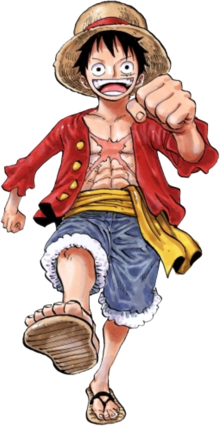

In [3]:
# get the image and open it

headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept": "image/*,*/*;q=0.8",
    "Referer": "https://en.wikipedia.org/"
}

response = requests.get('https://upload.wikimedia.org/wikipedia/en/c/cb/Monkey_D_Luffy.png', headers = headers)
image_file = BytesIO(response.content)
image = Image.open(image_file)
image

(np.float64(-0.5), np.float64(219.5), np.float64(425.5), np.float64(-0.5))

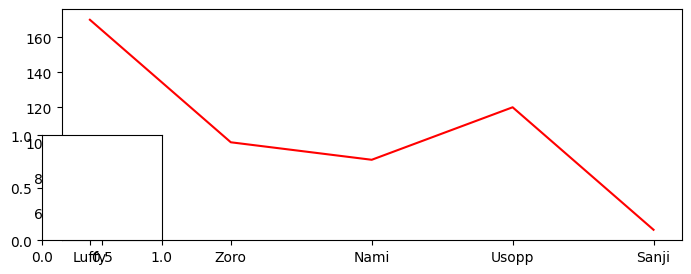

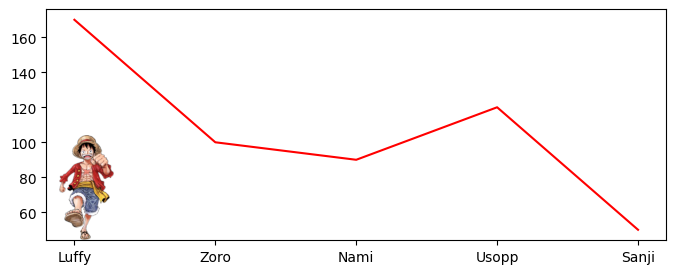

In [4]:
# get the same data
x = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])
y2 = np.array([170, 100, 90, 120, 50])

# create a simple plot
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(x, y2, color = "red")

# add only the image frame, first figure below
ax_image = fig.add_axes([0.1,
                        0.11,
                        0.15,
                        0.35]) 

# add the image into the plot, second figure below
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(x, y2,
        color = "red")
ax_image = fig.add_axes([0.1, 0.11, 0.15, 0.35])
ax_image.imshow(image)
ax_image.axis('off')

In [5]:
# saving the image
path = 'C:/Users/Desktop/"DSI 2025"/visulization'
# can be full path or relative path
filename = '/fig1a.png'

In [6]:
import seaborn as sns


In [7]:
tips = sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


[Text(0.5, 1.0, 'Tips versus Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

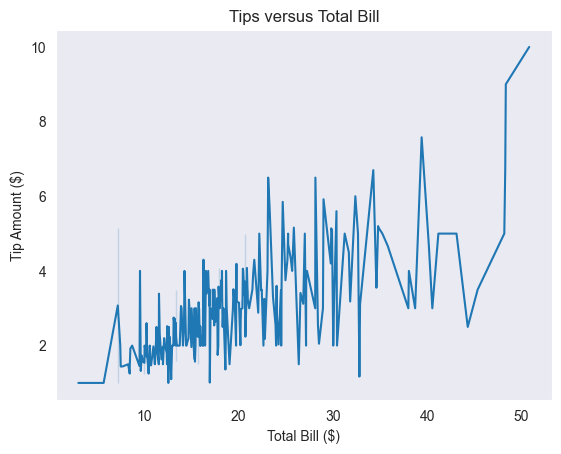

In [9]:
sns.set_style('dark')
tipgraph = sns.lineplot(data=tips,       # choose our dataset
           x='total_bill',  # define our x variable
           y='tip')         # define our y variable

tipgraph.set(title = 'Tips versus Total Bill',
             xlabel = 'Total Bill ($)',
             ylabel = 'Tip Amount ($)')

[Text(0.5, 1.0, 'Tips versus Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

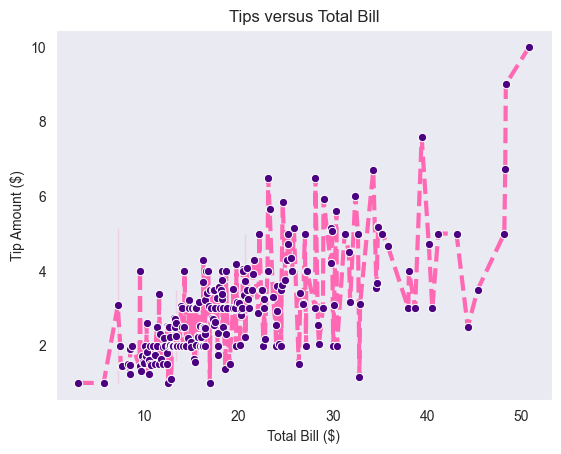

In [10]:
# updating some other aesthetic features of the graph
tipgraph_update = sns.lineplot(data=tips,
                      x='total_bill',
                      y='tip',
                      color = 'hotpink',
                      linestyle = '--',
                      linewidth = 3,
                      marker = 'o',
                      markerfacecolor = 'indigo')

tipgraph_update.set(title = 'Tips versus Total Bill',
             xlabel = 'Total Bill ($)',
             ylabel = 'Tip Amount ($)')

[Text(0.5, 1.0, 'Tips versus Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

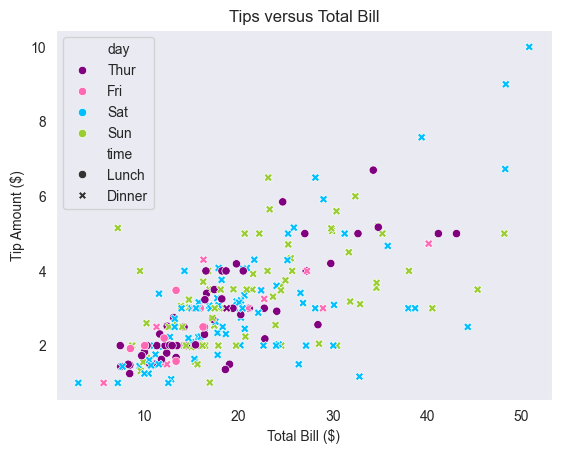

In [15]:
# Multiple variables
tipgraph_mulv = sns.scatterplot(data = tips, x = 'total_bill', 
                                y = 'tip',
                                style = 'time',
                                hue = 'day',
                                palette = ['purple', 'hotpink', 'deepskyblue', 'yellowgreen'])
tipgraph_mulv.set(title = 'Tips versus Total Bill',
             xlabel = 'Total Bill ($)',
             ylabel = 'Tip Amount ($)')


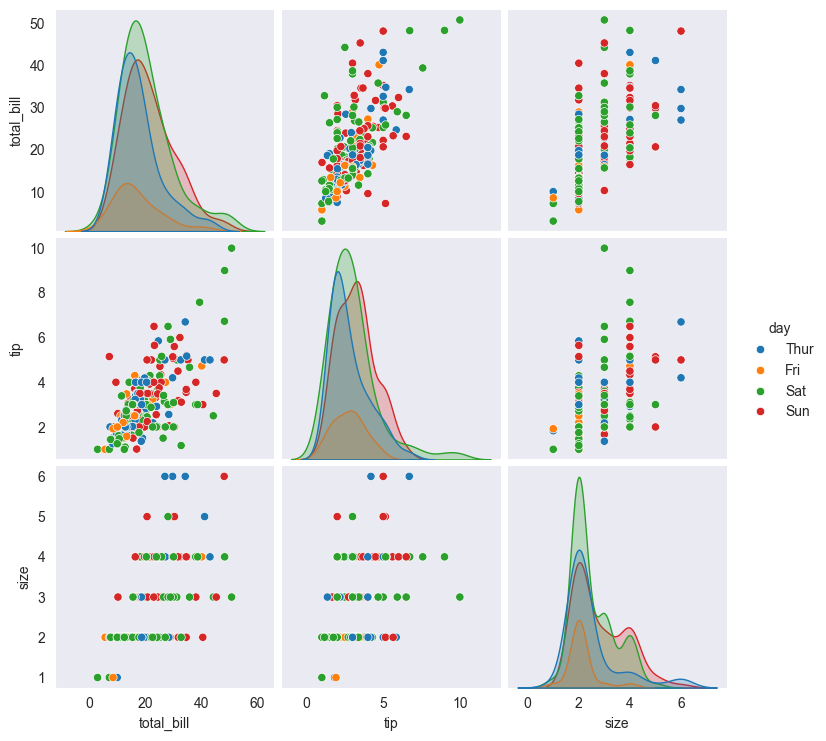

In [18]:
# Pair Plots
sns.pairplot(
    data = tips,
    hue = 'day'
)


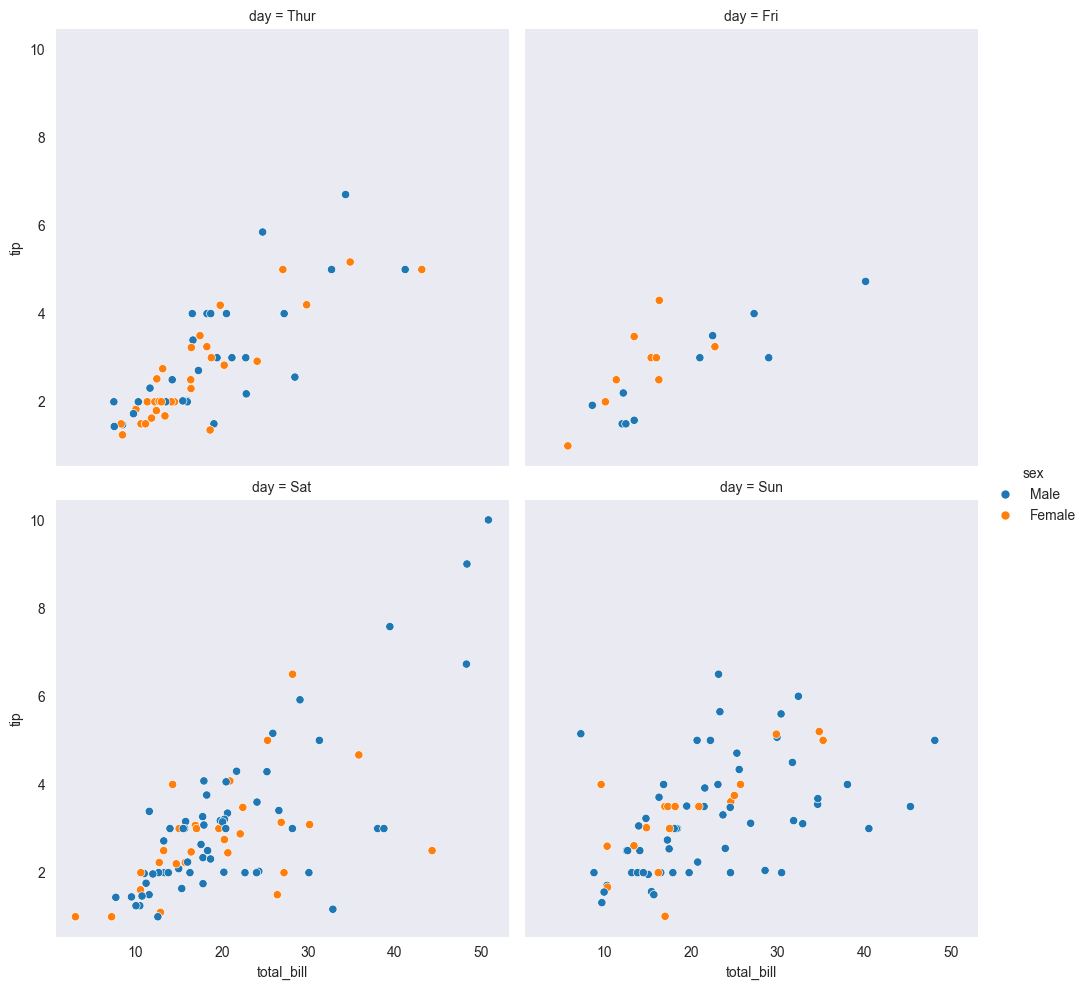

In [21]:
# Relplot
sns.relplot(data = tips,
           x = 'total_bill', y = 'tip',
           hue = 'sex', col = 'day', 
           kind = 'scatter', col_wrap = 2)

Activity: Type of changes
Type of changes when interacting:
When we type in a word, like professor, the graph changes the order of its y axis and (sometimes) the scale of its x axis. Therefore, this graph has immediate/transitional changes instead of being always identity-preserving.

What doesn't change:
The colors associated with male/female genders never changes regardless how we interact with the graph, ensuring a consistency for interpretation.

What changes:
The spatial locations of the dots changes when we enter a word. Also, as mentioned above, the x and y axis can both change in some perspectives.

How to improve:
Some dynamics tend to be redundant in this graph, including the reordering of y axis and the initial moving dots feature. In fact, I don't the the dynamic moving feature of the dots benefit any interpretation or storytelling, so I'd suggest to remove it.


In [1]:
# Plotly- dynamic data visualization

import plotly.graph_objects as go



In [4]:
x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

In [7]:
graph = go.Figure()
graph.add_trace(go.Bar(x = x1, y = y1))
graph.update_layout(title = 'Pirate Scores',
                    xaxis_title = 'Pirate',
                    yaxis_title = 'Score')

In [12]:
# more variations
graph = go.Figure()
graph.add_trace(go.Scatter(x = x1, y = y1, mode = 'markers',
                marker = dict(size = 15, color = 'hotpink',
                              opacity = 1,
                              line = dict(width = 5, color = 'purple'))))

graph.update_layout(title = 'Pirate Scores',
                    xaxis_title = 'Pirate',
                    yaxis_title = 'Score')


In [3]:
# Wordclouds
from wordcloud import WordCloud
df = pd.read_csv("https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv",
on_bad_lines='skip')
print(df)

                                                 quote  \
0                      Do, or do not. There is no try.   
1    Listen to them. Children of the night. What mu...   
2                              It's alive! It's alive!   
3    Oh, no, it wasn't the airplanes. It was Beauty...   
4    Magic Mirror on the wall, who is the fairest o...   
..                                                 ...   
727  I didn't know if you were lost. Stick with me....   
728  This guy's awesome! He's holding his own while...   
729     Murder is murder, it don’t matter who you are.   
730  You know what a lion is? A lion is a strong an...   
731  That was the best acting i've ever seen in my ...   

                                              movie   type  year  
0    Star Wars: Episode V - The Empire Strikes Back  movie  1890  
1                                           Dracula  movie  1931  
2                                      Frankenstein  movie  1931  
3                                  

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

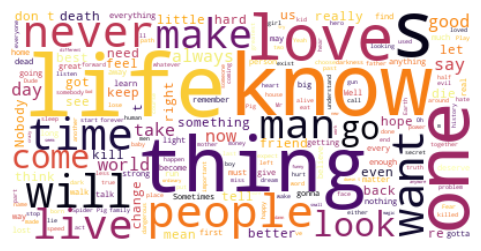

In [12]:
text = " ".join(each for each in df.quote)
wordcloud = WordCloud(background_color = 'white',
                      colormap = 'inferno').generate(text)
fig, ax = plt.subplots(figsize = (7, 3))
ax.imshow(wordcloud,
          interpolation = 'bilinear')
ax.axis("off")

In [13]:
# venn diagram
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

/Users/hesihan/Desktop/DSI 2025/visualization/visualization-env/lib/python3.11/site-packages/matplotlib_venn/_util.py:32: UserWarning: venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.
  warnings.warn(


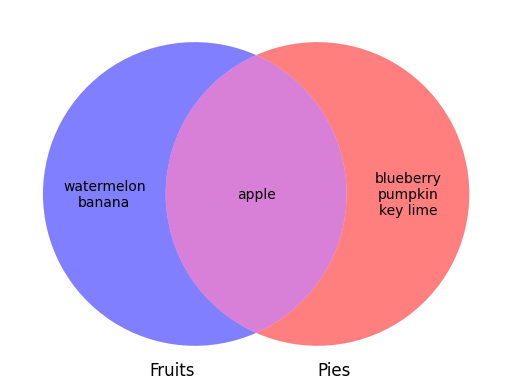

In [16]:
diagram = venn2_unweighted([A, B],
                            set_labels = ('Fruits', 'Pies'),
                            set_colors=("blue", "red"),
                            alpha=0.5)

diagram.get_label_by_id("10").set_text("\n".join(A - B))
# Overlapping region
diagram.get_label_by_id("11").set_text("\n".join(A & B))
# third region
diagram.get_label_by_id("01").set_text("\n".join(B - A))


